In [ ]:
import os

if os.environ.get("MEETING_DIARIZATION_ENV_READY") != "1":
    %pip -q install --upgrade pip setuptools wheel

    # Pin numeric stack
    %pip -q install --force-reinstall --no-cache-dir \
        "numpy==1.26.4" \
        "scipy==1.13.1" \
        "numba==0.60.0" \
        "librosa==0.10.2.post1" \
        "pandas==2.2.2"

    # Use pyannote.audio 4.x — fully compatible with modern torchaudio (2.4+)
    # Do NOT pin pyannote.audio==3.3.2 — it breaks on torchaudio>=2.4
    %pip -q install --no-cache-dir \
        "huggingface_hub>=0.23.0" \
        "transformers>=4.40.0" \
        openai-whisper \
        "pyannote.audio>=4.0.0" \
        "lightning>=2.1.0" \
        "torchmetrics>=1.0.0" \
        jiwer \
        datasets \
        soundfile \
        matplotlib

    os.environ["MEETING_DIARIZATION_ENV_READY"] = "1"
    print("✅ Dependencies installed.")
    print("⚠️  Now click Runtime > Restart Session, then run from Cell 2 onwards.")

else:
    print("✅ Environment already prepared.")

In [ ]:
import json
import os
import time
import numpy as np
import scipy
import torch
import torch.nn as nn
import torchaudio
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from collections import Counter, OrderedDict
from datasets import load_dataset
from jiwer import wer
from torch.utils.data import DataLoader, TensorDataset

# Verify torchaudio
print(f"torchaudio     : {torchaudio.__version__}")

# ── Install missing libs if needed ─────────────────────────────
# (Run once if error occurs)
# !pip install pyannote.audio whisper jiwer datasets

# ── Import pyannote ────────────────────────────────────────────
from pyannote.audio import Pipeline, Model, Inference
from pyannote.core import Segment
import whisper

print("✅ All imports successful")

# ── Config ─────────────────────────────────────────────────────
SAMPLE_RATE = 16000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WHISPER_MODEL = "large-v2"
EMBEDDING_MODEL = "pyannote/embedding"

# ── 🔐 HF Token via Kaggle Secrets ─────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    client = UserSecretsClient()
    HF_TOKEN = client.get_secret("HF_TOKEN")
except Exception as e:
    print("⚠️ Error loading HF_TOKEN from Kaggle Secrets:", e)
    HF_TOKEN = ""

# ── Dataset Config ─────────────────────────────────────────────
AMI_DATASET = "edinburghcstr/ami"
AMI_CONFIG = "ihm"
TRAIN_MEETING_IDS = ["EN2001a", "EN2001c", "EN2001d"]
DEMO_MEETING_ID = "EN2001b"
AMI_TARGET_MEETINGS = TRAIN_MEETING_IDS + [DEMO_MEETING_ID]

MAX_TRAIN_SEGMENTS_PER_MEETING = 40
MAX_DEMO_SECONDS = 300.0

OUTPUT_DIR = "/kaggle/working/outputs"

ATTRIBUTION_METHOD = "mlp"   # "mlp" or "cosine"
ENABLE_DENOISE = False
DENOISE_NOISE_SECONDS = 0.5

# ── Sanity checks ─────────────────────────────────────────────
if DEVICE != "cuda":
    print("⚠️ No GPU detected. Enable GPU in Settings → Accelerator → GPU")

if not HF_TOKEN:
    print("❌ HF_TOKEN is empty. Add it in Kaggle Secrets (Label: HF_TOKEN)")
else:
    print("✅ HF_TOKEN loaded successfully")

pipeline_start = time.perf_counter()
timings = {}

torch.manual_seed(42)
np.random.seed(42)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Print system info ──────────────────────────────────────────
print("\n===== SYSTEM INFO =====")
print("Device         :", DEVICE)
print("GPU Name       :", torch.cuda.get_device_name(0) if DEVICE=="cuda" else "CPU")
print("NumPy          :", np.__version__)
print("SciPy          :", scipy.__version__)
print("torchaudio     :", torchaudio.__version__)
print("Whisper model  :", WHISPER_MODEL)
print("Attribution    :", ATTRIBUTION_METHOD)
print("AMI config     :", AMI_CONFIG)
print("Target meetings:", AMI_TARGET_MEETINGS)
print("HF_TOKEN set   :", bool(HF_TOKEN))
print("=======================\n")

torchaudio     : 2.10.0+cu128
✅ All imports successful
✅ HF_TOKEN loaded successfully

===== SYSTEM INFO =====
Device         : cuda
GPU Name       : Tesla T4
NumPy          : 2.4.4
SciPy          : 1.17.1
torchaudio     : 2.10.0+cu128
Whisper model  : large-v2
Attribution    : mlp
AMI config     : ihm
Target meetings: ['EN2001a', 'EN2001c', 'EN2001d', 'EN2001b']
HF_TOKEN set   : True



In [ ]:
from itertools import chain

download_start = time.perf_counter()


def simplify_ami_example(example):
    return {
        "meeting_id": example["meeting_id"],
        "speaker_id": str(example["speaker_id"]),
        "text": str(example["text"]),
        "begin_time": float(example["begin_time"]),
        "end_time": float(example["end_time"]),
        "audio": {
            "array": np.asarray(example["audio"]["array"], dtype=np.float32),
            "sampling_rate": int(example["audio"]["sampling_rate"]),
        },
    }


def collect_ami_target_meetings():
    splits = ["train", "validation", "test"]
    streams = [
        load_dataset(AMI_DATASET, AMI_CONFIG, split=s, streaming=True)
        for s in splits
    ]
    stream = chain(*streams)

    # ── Auto-discover which target meetings actually exist in this config ────
    # Instead of failing hard on missing IDs, we collect whatever is available
    # from AMI_TARGET_MEETINGS and warn about any that are absent.
    meetings = OrderedDict((mid, []) for mid in AMI_TARGET_MEETINGS)

    for example in stream:
        meeting_id = example["meeting_id"]
        if meeting_id not in meetings:
            continue

        begin_time = float(example["begin_time"])
        if meeting_id == DEMO_MEETING_ID and begin_time >= MAX_DEMO_SECONDS:
            continue

        is_train = meeting_id in TRAIN_MEETING_IDS
        limit = MAX_TRAIN_SEGMENTS_PER_MEETING if is_train else 10**9
        if len(meetings[meeting_id]) >= limit:
            # Check if we have enough data to stop early
            available_train_ids = [
                mid for mid in TRAIN_MEETING_IDS if len(meetings[mid]) > 0
            ]
            enough_training = (
                len(available_train_ids) > 0
                and all(
                    len(meetings[mid]) >= MAX_TRAIN_SEGMENTS_PER_MEETING
                    for mid in available_train_ids
                )
            )
            demo_ready = (
                len(meetings[DEMO_MEETING_ID]) > 0
                and meetings[DEMO_MEETING_ID][-1]["end_time"] >= MAX_DEMO_SECONDS - 5.0
            )
            if enough_training and demo_ready:
                break
            continue

        meetings[meeting_id].append(simplify_ami_example(example))

        available_train_ids = [
            mid for mid in TRAIN_MEETING_IDS if len(meetings[mid]) > 0
        ]
        enough_training = (
            len(available_train_ids) > 0
            and all(
                len(meetings[mid]) >= MAX_TRAIN_SEGMENTS_PER_MEETING
                for mid in available_train_ids
            )
        )
        demo_ready = (
            len(meetings[DEMO_MEETING_ID]) > 0
            and meetings[DEMO_MEETING_ID][-1]["end_time"] >= MAX_DEMO_SECONDS - 5.0
        )
        if enough_training and demo_ready:
            break

    # ── Warn about missing meetings instead of crashing ──────────────────────
    missing = [mid for mid, examples in meetings.items() if not examples]
    if missing:
        print(f"⚠️  These meeting IDs were not found in '{AMI_CONFIG}' config and will be skipped: {missing}")
        for mid in missing:
            del meetings[mid]

    # ── Require at least the demo meeting and 1 training meeting ─────────────
    if DEMO_MEETING_ID not in meetings or not meetings[DEMO_MEETING_ID]:
        raise ValueError(
            f"Demo meeting '{DEMO_MEETING_ID}' not found in dataset. "
            f"Change DEMO_MEETING_ID in Cell 2."
        )

    available_train = [mid for mid in TRAIN_MEETING_IDS if mid in meetings and meetings[mid]]
    if not available_train:
        raise ValueError(
            "No training meetings found. Check TRAIN_MEETING_IDS in Cell 2."
        )

    return meetings


ami_meetings = collect_ami_target_meetings()

# ── Rebuild train list from only the meetings that were actually found ────────
train_examples = []
for meeting_id in TRAIN_MEETING_IDS:
    if meeting_id in ami_meetings:
        train_examples.extend(ami_meetings[meeting_id])

demo_examples = sorted(ami_meetings[DEMO_MEETING_ID], key=lambda x: x["begin_time"])
timings["ami_subset_download"] = time.perf_counter() - download_start

print("✅ Collected AMI subset successfully.")
for meeting_id, examples in ami_meetings.items():
    role = "DEMO" if meeting_id == DEMO_MEETING_ID else "TRAIN"
    print(f"  [{role}] {meeting_id} -> {len(examples)} segments")
print(f"Total training segments : {len(train_examples)}")
print(f"Total demo segments     : {len(demo_examples)}")
print(f"AMI subset collection time: {timings['ami_subset_download']:.2f}s")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

⚠️  These meeting IDs were not found in 'ihm' config and will be skipped: ['EN2001c', 'EN2001d']
✅ Collected AMI subset successfully.
  [TRAIN] EN2001a -> 40 segments
  [DEMO] EN2001b -> 10 segments
Total training segments : 40
Total demo segments     : 10
AMI subset collection time: 6.62s


In [ ]:
ATTRIBUTION_EPOCHS = 8
ATTRIBUTION_BATCH_SIZE = 32
ATTRIBUTION_LR = 1e-3
COSINE_THRESHOLD = 0.65


def load_audio(path):
    audio, sr = librosa.load(path, sr=None, mono=True)
    return audio.astype(np.float32), sr


def spectral_subtract_denoise(audio, sr, noise_seconds=DENOISE_NOISE_SECONDS):
    if len(audio) == 0:
        return audio.astype(np.float32)
    n_fft = 512
    hop_length = 128
    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(stft)
    phase = np.angle(stft)
    noise_frames = max(1, int((noise_seconds * sr) / hop_length))
    noise_profile = np.mean(magnitude[:, :noise_frames], axis=1, keepdims=True)
    cleaned_magnitude = np.maximum(magnitude - noise_profile, 0.0)
    cleaned = librosa.istft(cleaned_magnitude * np.exp(1j * phase), hop_length=hop_length, length=len(audio))
    return cleaned.astype(np.float32)


def preprocess_audio(audio, sr, apply_denoise=ENABLE_DENOISE):
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        sr = SAMPLE_RATE
    if apply_denoise:
        audio = spectral_subtract_denoise(audio, sr)
    peak = np.max(np.abs(audio)) + 1e-9
    audio = (audio / peak).astype(np.float32)
    return audio, sr


def format_timestamp(seconds):
    s = int(max(0, round(seconds)))
    h, rem = divmod(s, 3600)
    m, sec = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{sec:02d}"


def render_speaker_label(label):
    label = str(label)
    if label.startswith("SPEAKER_"):
        return f"Speaker {label.split('_')[-1]}"
    return label


def build_demo_meeting_audio(examples, output_path):
    duration = max(example["end_time"] for example in examples) + 1.0
    waveform = np.zeros(int(duration * SAMPLE_RATE), dtype=np.float32)
    reference_segments = []

    for example in sorted(examples, key=lambda x: x["begin_time"]):
        audio = np.asarray(example["audio"]["array"], dtype=np.float32)
        sr = int(example["audio"]["sampling_rate"])
        audio, sr = preprocess_audio(audio, sr)

        start_idx = int(example["begin_time"] * sr)
        end_idx = min(start_idx + len(audio), len(waveform))
        waveform[start_idx:end_idx] += audio[: end_idx - start_idx]

        reference_segments.append({
            "start": float(example["begin_time"]),
            "end": float(example["end_time"]),
            "speaker": str(example["speaker_id"]),
            "text": str(example["text"]),
        })

    waveform, _ = preprocess_audio(waveform, SAMPLE_RATE)
    sf.write(output_path, waveform, SAMPLE_RATE)
    return output_path, reference_segments


class SpeakerAttributionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def encode_labels(labels):
    unique_labels = sorted(set(labels))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    idx_to_label = {idx: label for label, idx in label_to_idx.items()}
    encoded = np.array([label_to_idx[label] for label in labels], dtype=np.int64)
    return encoded, idx_to_label


def train_speaker_model(embeddings, labels, epochs=8, batch_size=32, lr=1e-3):
    y, idx_to_label = encode_labels(labels)
    dataset = TensorDataset(
        torch.tensor(embeddings, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SpeakerAttributionMLP(
        input_dim=embeddings.shape[1],
        hidden_dim=128,
        num_classes=len(idx_to_label),
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=-1) == yb).sum().item()
            total_samples += xb.size(0)

        epoch_loss = total_loss / max(total_samples, 1)
        epoch_acc = total_correct / max(total_samples, 1)
        print(f"Epoch {epoch + 1}/{epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

    model.eval()
    return model, idx_to_label


def l2_normalize(x):
    denom = np.linalg.norm(x) + 1e-9
    return x / denom


def build_speaker_prototypes(embeddings, labels):
    grouped = OrderedDict()
    for emb, label in zip(embeddings, labels):
        grouped.setdefault(label, []).append(emb)
    prototypes = {
        label: l2_normalize(np.mean(np.stack(items).astype(np.float32), axis=0))
        for label, items in grouped.items()
    }
    return prototypes


def predict_speaker_cosine(embedding, prototypes):
    embedding = l2_normalize(np.asarray(embedding, dtype=np.float32))
    best_label = None
    best_score = -1.0
    for label, proto in prototypes.items():
        score = float(np.dot(embedding, proto))
        if score > best_score:
            best_score = score
            best_label = label
    confidence = max(0.0, min(1.0, (best_score + 1.0) / 2.0))
    return best_label, confidence


def extract_embedding_from_array(audio, sr):
    """Extract speaker embedding from a numpy audio array."""
    if len(audio) < int(0.3 * sr):
        return None
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    waveform = torch.tensor(audio, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, T)
    with torch.no_grad():
        embedding = embedding_inference({"waveform": waveform, "sample_rate": SAMPLE_RATE})
    embedding = np.asarray(embedding, dtype=np.float32).squeeze()
    if embedding.ndim != 1:
        embedding = embedding.reshape(-1)
    return embedding


def extract_segment_embedding(audio_path, start, end):
    """Extract speaker embedding for a time segment from a file."""
    if end - start < 0.3:
        return None
    audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE, offset=start, duration=end - start, mono=True)
    audio = audio.astype(np.float32)
    if len(audio) < int(0.3 * SAMPLE_RATE):
        return None
    waveform = torch.tensor(audio, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, T)
    with torch.no_grad():
        embedding = embedding_inference({"waveform": waveform, "sample_rate": SAMPLE_RATE})
    embedding = np.asarray(embedding, dtype=np.float32).squeeze()
    if embedding.ndim != 1:
        embedding = embedding.reshape(-1)
    return embedding


def predict_speaker_mlp(embedding, model, idx_to_label):
    with torch.no_grad():
        x = torch.tensor(embedding, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)[0]
        pred_idx = int(torch.argmax(probs).item())
        confidence = float(probs[pred_idx].item())
    return idx_to_label[pred_idx], confidence


def asr_confidence_from_output(output):
    scores = [seg.get("avg_logprob") for seg in output.get("segments", []) if seg.get("avg_logprob") is not None]
    if not scores:
        return None
    mean_logprob = float(np.mean(scores))
    return float(np.clip(np.exp(mean_logprob), 0.0, 1.0))


def diarization_confidence_heuristic(segment):
    duration = float(segment["end"] - segment["start"])
    return float(np.clip(duration / 1.5, 0.35, 1.0))


def combine_confidence(asr_confidence, diar_confidence):
    if asr_confidence is None:
        return diar_confidence
    return float(np.clip(asr_confidence * diar_confidence, 0.0, 1.0))


def merge_small_segments(segs, min_duration=0.5, gap_tolerance=0.2):
    merged = []
    for seg in segs:
        duration = seg["end"] - seg["start"]
        if (merged
                and duration < min_duration
                and merged[-1]["speaker"] == seg["speaker"]
                and seg["start"] - merged[-1]["end"] <= gap_tolerance):
            merged[-1]["end"] = max(merged[-1]["end"], seg["end"])
        else:
            merged.append(seg.copy())
    return merged


def reference_speaker_for_segment(start, end, reference_segments):
    best_speaker = None
    best_overlap = 0.0
    for ref in reference_segments:
        overlap = max(0.0, min(end, ref["end"]) - max(start, ref["start"]))
        if overlap > best_overlap:
            best_overlap = overlap
            best_speaker = ref["speaker"]
    return best_speaker


def compute_der_approx(pred_segments, ref_segments, step=0.1):
    max_time = max(
        max(seg["end"] for seg in pred_segments),
        max(seg["end"] for seg in ref_segments)
    )
    total = 0
    errors = 0
    t = 0.0
    while t < max_time:
        pred = reference_speaker_for_segment(t, t + step, pred_segments)
        ref  = reference_speaker_for_segment(t, t + step, ref_segments)
        if ref is not None:
            total += 1
            if pred != ref:
                errors += 1
        t += step
    return errors / total if total else 0.0


def build_reference_transcript(reference_segments):
    return " ".join(seg["text"].strip() for seg in reference_segments if seg["text"].strip())


def build_predicted_transcript(results):
    return " ".join(item["text"].strip() for item in results if item["text"].strip())


def plot_speaker_timeline(results, output_path):
    labels = list(OrderedDict.fromkeys(item["speaker"] for item in results))
    y_map = {label: idx for idx, label in enumerate(labels)}
    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(labels))))
    color_map = {label: colors[idx] for idx, label in enumerate(labels)}

    plt.figure(figsize=(14, 2 + 0.6 * len(labels)))
    for item in results:
        y = y_map[item["speaker"]]
        plt.barh(
            y=y,
            width=item["end"] - item["start"],
            left=item["start"],
            color=color_map[item["speaker"]],
            edgecolor="black",
            alpha=0.85,
        )

    plt.yticks(list(y_map.values()), [render_speaker_label(label) for label in labels])
    plt.xlabel("Time (seconds)")
    plt.ylabel("Speaker")
    plt.title("Predicted Speaker Turns")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close()


# ── Confirmation ──────────────────────────────────────────────────────────────
print("✅ Cell 4 complete — all helper functions defined successfully.")
print(f"   Attribution method : {ATTRIBUTION_METHOD}")
print(f"   Attribution epochs : {ATTRIBUTION_EPOCHS}")
print(f"   Batch size         : {ATTRIBUTION_BATCH_SIZE}")
print(f"   Learning rate      : {ATTRIBUTION_LR}")
print(f"   Cosine threshold   : {COSINE_THRESHOLD}")
print(f"   Denoising enabled  : {ENABLE_DENOISE}")

✅ Cell 4 complete — all helper functions defined successfully.
   Attribution method : mlp
   Attribution epochs : 8
   Batch size         : 32
   Learning rate      : 0.001
   Cosine threshold   : 0.65
   Denoising enabled  : False


In [ ]:
import gc
from huggingface_hub import HfApi

model_load_start = time.perf_counter()

# ── Validate HF token and model access before loading ────────────────────────
def check_hf_access(repo_id, token):
    try:
        api = HfApi()
        api.model_info(repo_id, token=token)
        print(f"  ✅ Access confirmed: {repo_id}")
        return True
    except Exception as e:
        err = str(e)
        if "403" in err or "gated" in err.lower():
            print(f"  ❌ Access DENIED: {repo_id}")
            print(f"     → Visit https://huggingface.co/{repo_id} and click 'Agree and access repository'")
        elif "401" in err or "token" in err.lower():
            print(f"  ❌ Invalid token for: {repo_id}")
            print(f"     → Check your HF_TOKEN at https://huggingface.co/settings/tokens")
        else:
            print(f"  ❌ Error accessing {repo_id}: {e}")
        return False

print("Checking Hugging Face model access...")
models_to_check = [
    "pyannote/speaker-diarization-3.1",
    "pyannote/segmentation-3.0",
    "pyannote/embedding",
]
all_ok = all(check_hf_access(m, HF_TOKEN) for m in models_to_check)

if not all_ok:
    raise PermissionError(
        "\n\n❌ Cannot proceed — one or more models are not accessible.\n"
        "Please:\n"
        "  1. Visit each ❌ URL above and click 'Agree and access repository'\n"
        "  2. Make sure your HF token has 'read' permission:\n"
        "     https://huggingface.co/settings/tokens\n"
        "  3. Re-run this cell after accepting access.\n"
    )

# ── Load diarization pipeline ─────────────────────────────────────────────────
print("\nLoading pyannote diarization pipeline...")
diar_pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token=HF_TOKEN,
)
if DEVICE == "cuda":
    diar_pipeline.to(torch.device("cuda"))
print("  ✅ Diarization pipeline loaded")

torch.cuda.empty_cache()
gc.collect()

# ── Load Whisper ASR ──────────────────────────────────────────────────────────
print("Loading Whisper ASR model...")
asr_model = whisper.load_model(WHISPER_MODEL, device=DEVICE)
print("  ✅ Whisper loaded")

torch.cuda.empty_cache()
gc.collect()

# ── Load speaker embedding model ──────────────────────────────────────────────
print("Loading speaker embedding model...")
embedding_model = Model.from_pretrained(
    "pyannote/embedding",
    token=HF_TOKEN,
)
embedding_model = embedding_model.to(torch.device(DEVICE))
embedding_inference = Inference(embedding_model, window="whole")
print("  ✅ Embedding model loaded")

timings["model_load"] = time.perf_counter() - model_load_start
print(f"\n✅ All models loaded in {timings['model_load']:.2f}s")
print(f"   Device: {DEVICE}")

Checking Hugging Face model access...
  ✅ Access confirmed: pyannote/speaker-diarization-3.1
  ✅ Access confirmed: pyannote/segmentation-3.0
  ✅ Access confirmed: pyannote/embedding

Loading pyannote diarization pipeline...


config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

...

  ✅ Whisper loaded
Loading speaker embedding model...


pytorch_model.bin:   0%|          | 0.00/96.4M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/utils.py:197: Redirecting import of pytorch_lightning.callbacks.early_stopping.EarlyStopping to lightning.pytorch.callbacks.early_stopping.EarlyStopping
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/utils.py:197: Redirecting import of pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint to lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.1. To apply the upgrade

  ✅ Embedding model loaded

✅ All models loaded in 59.43s
   Device: cuda


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['loss_func.W']


In [ ]:
import gc
import os

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

model_load_start = time.perf_counter()

# ── Step 1: Force free ALL GPU memory before loading anything ─────────────────
torch.cuda.empty_cache()
torch.cuda.synchronize()
gc.collect()
print(f"GPU memory at start: {torch.cuda.memory_allocated()/1e9:.2f} GB used")

# ── Step 2: Load Whisper FIRST (before pyannote touches GPU) ──────────────────
# Use 'small' — reliable fit on T4 alongside pyannote (~2GB vs medium's 5GB)
WHISPER_MODEL = "small"
print(f"\nLoading Whisper ASR model ('{WHISPER_MODEL}') first...")
asr_model = whisper.load_model(WHISPER_MODEL, device=DEVICE)
torch.cuda.empty_cache()
gc.collect()
print(f"  ✅ Whisper loaded | GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB used")

# ── Step 3: Load embedding model ──────────────────────────────────────────────
print("\nLoading speaker embedding model...")
embedding_model = Model.from_pretrained(
    EMBEDDING_MODEL,
    token=HF_TOKEN if HF_TOKEN else None,
)
embedding_model = embedding_model.to(torch.device(DEVICE))
embedding_inference = Inference(embedding_model, window="whole")
torch.cuda.empty_cache()
gc.collect()
print(f"  ✅ Embedding loaded | GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB used")

# ── Step 4: Load pyannote pipeline on CPU only — NEVER move to GPU ────────────
# pyannote will run on CPU during diarization to avoid OOM
print("\nLoading pyannote diarization pipeline (CPU only)...")
try:
    diar_pipeline = Pipeline.from_pretrained(
        "pyannote/speaker-diarization-3.1",
        token=HF_TOKEN if HF_TOKEN else None,
    )
except Exception as e:
    if "community" in str(e).lower() or "plda" in str(e).lower() or "403" in str(e):
        print("  ⚠️  PLDA repo blocked, loading without PLDA...")
        from pyannote.audio.pipelines import SpeakerDiarization
        seg_model = Model.from_pretrained(
            "pyannote/segmentation-3.0",
            token=HF_TOKEN if HF_TOKEN else None,
        )
        diar_pipeline = SpeakerDiarization(
            segmentation=seg_model,
            embedding="pyannote/embedding",
            embedding_exclude_overlap=True,
            clustering="AgglomerativeClustering",
        )
        diar_pipeline.instantiate({
            "segmentation": {"min_duration_off": 0.0},
            "clustering": {
                "method": "centroid",
                "min_cluster_size": 12,
                "threshold": 0.7153814381597874,
            },
        })
    else:
        raise

# Keep pyannote on CPU — do NOT call .to("cuda")
diar_pipeline.to(torch.device("cpu"))
gc.collect()
print(f"  ✅ Pyannote loaded on CPU | GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB used")

# ── Diarization helper — runs fully on CPU ────────────────────────────────────
def run_diarization(audio_path):
    """Run diarization on CPU to avoid GPU OOM."""
    gc.collect()
    result = diar_pipeline(audio_path)  # runs on CPU
    gc.collect()
    return result

timings["model_load"] = time.perf_counter() - model_load_start
print(f"\n✅ All models loaded in {timings['model_load']:.2f}s")
print(f"   Device        : {DEVICE}")
print(f"   Whisper model : {WHISPER_MODEL}")
print(f"   Pyannote      : CPU only")
print(f"   Final GPU use : {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU memory at start: 6.33 GB used

Loading Whisper ASR model ('small') first...


100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 274MiB/s]


  ✅ Whisper loaded | GPU: 1.02 GB used

Loading speaker embedding model...


Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--pyannote--embedding/snapshots/4db4899737a38b2d618bbd74350915aa10293cb2/pytorch_model.bin`
Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--pyannote--embedding/snapshots/4db4899737a38b2d618bbd74350915aa10293cb2/pytorch_model.bin`


  ✅ Embedding loaded | GPU: 1.02 GB used

Loading pyannote diarization pipeline (CPU only)...
  ✅ Pyannote loaded on CPU | GPU: 1.02 GB used

✅ All models loaded in 7.87s
   Device        : cuda
   Whisper model : small
   Pyannote      : CPU only
   Final GPU use : 1.02 GB


In [ ]:
def extract_embedding_from_array(audio, sr):
    """Extract speaker embedding from a numpy audio array."""
    if len(audio) < int(0.3 * sr):
        return None
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    # pyannote expects (channel, time) — 2D tensor, NOT (1, 1, T)
    waveform = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)  # (1, T)
    with torch.no_grad():
        embedding = embedding_inference({"waveform": waveform, "sample_rate": SAMPLE_RATE})
    embedding = np.asarray(embedding, dtype=np.float32).squeeze()
    if embedding.ndim != 1:
        embedding = embedding.reshape(-1)
    return embedding


def extract_segment_embedding(audio_path, start, end):
    """Extract speaker embedding for a time segment from a file."""
    if end - start < 0.3:
        return None
    audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE, offset=start, duration=end - start, mono=True)
    audio = audio.astype(np.float32)
    if len(audio) < int(0.3 * SAMPLE_RATE):
        return None
    # pyannote expects (channel, time) — 2D tensor, NOT (1, 1, T)
    waveform = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)  # (1, T)
    with torch.no_grad():
        embedding = embedding_inference({"waveform": waveform, "sample_rate": SAMPLE_RATE})
    embedding = np.asarray(embedding, dtype=np.float32).squeeze()
    if embedding.ndim != 1:
        embedding = embedding.reshape(-1)
    return embedding

print("✅ Embedding functions patched — (1, T) shape fixed.")

✅ Embedding functions patched — (1, T) shape fixed.


In [4]:
attribution_start = time.perf_counter()
train_embeddings = []
train_labels = []

for example in train_examples:
    audio = np.asarray(example["audio"]["array"], dtype=np.float32)
    sr = int(example["audio"]["sampling_rate"])
    audio, sr = preprocess_audio(audio, sr)
    embedding = extract_embedding_from_array(audio, sr)
    if embedding is None:
        continue
    train_embeddings.append(embedding)
    train_labels.append(str(example["speaker_id"]))

if len(train_embeddings) == 0:
    raise ValueError("No AMI training embeddings were extracted.")

train_embeddings = np.stack(train_embeddings).astype(np.float32)
num_speakers = len(set(train_labels))
if num_speakers < 2:
    raise ValueError("Need at least two AMI speakers to train the speaker attribution model.")

print("Preparing speaker attribution from AMI only...")
print("Training utterances:", len(train_embeddings))
print("Unique AMI speakers:", num_speakers)
print("Speaker distribution:", Counter(train_labels))

speaker_classifier = None
idx_to_label = None
speaker_prototypes = None

if ATTRIBUTION_METHOD == "mlp":
    speaker_classifier, idx_to_label = train_speaker_model(
        train_embeddings,
        train_labels,
        epochs=ATTRIBUTION_EPOCHS,
        batch_size=ATTRIBUTION_BATCH_SIZE,
        lr=ATTRIBUTION_LR,
    )
    print("Using notebook-only MLP attribution.")
elif ATTRIBUTION_METHOD == "cosine":
    speaker_prototypes = build_speaker_prototypes(train_embeddings, train_labels)
    print("Using cosine-similarity speaker prototypes.")
else:
    raise ValueError("ATTRIBUTION_METHOD must be 'mlp' or 'cosine'.")

timings["speaker_attribution_setup"] = time.perf_counter() - attribution_start
print(f"Speaker attribution setup time: {timings['speaker_attribution_setup']:.2f}s")

Preparing speaker attribution from AMI only...
Training utterances: 37
Unique AMI speakers: 5
Speaker distribution: Counter({'MEO069': 20, 'MEE067': 10, 'FEO066': 3, 'MEE068': 2, 'FEO065': 2})

Epoch 1/8 - loss: 1.9137 - acc: 0.3186
Epoch 2/8 - loss: 1.4725 - acc: 0.4521
Epoch 3/8 - loss: 1.2483 - acc: 0.5217
Epoch 4/8 - loss: 1.1304 - acc: 0.5578
Epoch 5/8 - loss: 1.0622 - acc: 0.5813
Epoch 6/8 - loss: 1.0189 - acc: 0.5954
Epoch 7/8 - loss: 0.9921 - acc: 0.6027
Epoch 8/8 - loss: 0.9785 - acc: 0.6056

Using notebook-only MLP attribution.
Speaker attribution setup time: 1.64s


In [ ]:
def run_diarization(audio_path):
    """Run diarization on CPU, handles both pyannote 3.x and 4.x output formats."""
    gc.collect()
    result = diar_pipeline(audio_path)
    gc.collect()
    return result


def parse_diarization(diar):
    """Parse pyannote 4.x DiarizeOutput using .speaker_diarization attribute."""
    speaker_map = {}
    speaker_id = 1
    segments = []

    # ── pyannote 4.x: DiarizeOutput.speaker_diarization is the Annotation ────
    if hasattr(diar, 'speaker_diarization'):
        annotation = diar.speaker_diarization
    elif hasattr(diar, 'exclusive_speaker_diarization'):
        annotation = diar.exclusive_speaker_diarization
    elif hasattr(diar, 'itertracks'):
        annotation = diar  # already an Annotation (pyannote 3.x)
    else:
        raise ValueError(f"Cannot find annotation in DiarizeOutput. attrs: {dir(diar)}")

    for turn, _, speaker in annotation.itertracks(yield_label=True):
        if speaker not in speaker_map:
            speaker_map[speaker] = f"SPEAKER_{speaker_id}"
            speaker_id += 1
        segments.append({
            "start": float(turn.start),
            "end": float(turn.end),
            "speaker": speaker_map[speaker],
        })

    print(f"  ✅ Parsed {len(segments)} segments from {type(annotation).__name__}")
    return segments

print("✅ parse_diarization fixed — using .speaker_diarization attribute")

✅ parse_diarization fixed — using .speaker_diarization attribute


In [2]:
import gc

# ── Rebuild missing variables if needed ───────────────────────────────────────
if "demo_audio_path" not in dir() or not os.path.exists(demo_audio_path):
    print("⚠️  demo_audio_path missing — rebuilding demo audio now...")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    demo_audio_path = os.path.join(OUTPUT_DIR, f"{DEMO_MEETING_ID}_auto_demo.wav")
    demo_audio_path, reference_segments = build_demo_meeting_audio(demo_examples, demo_audio_path)
    print(f"  ✅ Demo audio rebuilt: {demo_audio_path}")
    print(f"  ✅ Reference segments: {len(reference_segments)}")

if "segments" not in dir() or not segments:
    print("⚠️  Diarization segments missing — running diarization now...")
    diar = run_diarization(demo_audio_path)
    segments = parse_diarization(diar)          # ← uses new parser
    segments = sorted(segments, key=lambda x: (x["start"], x["end"]))
    segments = merge_small_segments(segments)
    for seg in segments:
        seg["embedding"] = extract_segment_embedding(demo_audio_path, seg["start"], seg["end"])
    print(f"  ✅ Diarized segments: {len(segments)}")

# ── ASR + attribution ─────────────────────────────────────────────────────────
asr_start = time.perf_counter()
audio, sr = load_audio(demo_audio_path)
audio, sr = preprocess_audio(audio, sr)
audio_duration_s = len(audio) / sr

results = []
with torch.no_grad():
    for seg in segments:
        st, et = seg["start"], seg["end"]
        diar_speaker = seg["speaker"]
        reference_speaker = reference_speaker_for_segment(st, et, reference_segments)
        x0 = max(0, int(st * sr))
        x1 = max(x0, int(et * sr))
        chunk = audio[x0:x1]

        if seg["embedding"] is not None and ATTRIBUTION_METHOD == "mlp":
            attributed_speaker, attribution_confidence = predict_speaker_mlp(
                seg["embedding"], speaker_classifier, idx_to_label,
            )
        elif seg["embedding"] is not None and ATTRIBUTION_METHOD == "cosine":
            attributed_speaker, attribution_confidence = predict_speaker_cosine(
                seg["embedding"], speaker_prototypes,
            )
        else:
            attributed_speaker, attribution_confidence = diar_speaker, None

        if len(chunk) < int(0.1 * sr):
            text = ""
            asr_confidence = None
        else:
            out = asr_model.transcribe(
                chunk,
                fp16=(DEVICE == "cuda"),
                verbose=False,
                task="transcribe",
            )
            text = out.get("text", "").strip()
            asr_confidence = asr_confidence_from_output(out)

        diar_confidence = diarization_confidence_heuristic(seg)
        final_confidence = combine_confidence(
            asr_confidence,
            attribution_confidence if attribution_confidence is not None else diar_confidence,
        )

        results.append({
            "start": st,
            "end": et,
            "speaker": attributed_speaker,
            "diarization_speaker": diar_speaker,
            "reference_speaker": reference_speaker,
            "text": text,
            "asr_confidence": asr_confidence,
            "attribution_confidence": attribution_confidence,
            "diarization_confidence": diar_confidence,
            "confidence": final_confidence,
        })

timings["segment_asr_and_attribution"] = time.perf_counter() - asr_start

scored = [item for item in results if item["reference_speaker"] is not None]
attribution_accuracy = (
    sum(item["speaker"] == item["reference_speaker"] for item in scored) / len(scored)
    if scored else None
)

pred_segments = [{"start": item["start"], "end": item["end"], "speaker": item["speaker"]} for item in results]
pred_text = build_predicted_transcript(results)
ref_text = build_reference_transcript(reference_segments)
wer_score = wer(ref_text, pred_text) if ref_text else None
der_score = compute_der_approx(pred_segments, reference_segments)
rtf = timings["segment_asr_and_attribution"] / max(audio_duration_s, 1e-9)
timings["total"] = time.perf_counter() - pipeline_start

print("✅ Transcription complete")
print(f"   Transcribed segments : {len(results)}")
print(f"   Audio duration       : {audio_duration_s:.2f}s")
print(f"   ASR + attribution    : {timings['segment_asr_and_attribution']:.2f}s")
print(f"   RTF                  : {rtf:.4f}")
if wer_score is not None:
    print(f"   WER                  : {wer_score:.4f}")
print(f"   Approx DER           : {der_score:.4f}")

✅ Parsed 9 segments from Annotation
✅ Diarized segments: 9

Detected language: English
100%|██████████| 168500/168500 [00:01<00:00, 131.35frames/s]

Detected language: English
100%|██████████| 97500/97500 [00:00<00:00, 131.23frames/s]

Detected language: English
100%|██████████| 30500/30500 [00:00<00:00, 131.21frames/s]

Detected language: English
100%|██████████| 17800/17800 [00:00<00:00, 131.15frames/s]

Detected language: English
100%|██████████| 15000/15000 [00:00<00:00, 131.18frames/s]

Detected language: English
100%|██████████| 102700/102700 [00:00<00:00, 131.27frames/s]

Detected language: English
100%|██████████| 10700/10700 [00:00<00:00, 131.10frames/s]

Detected language: English
100%|██████████| 26500/26500 [00:00<00:00, 131.22frames/s]

Detected language: English
100%|██████████| 130800/130800 [00:01<00:00, 131.30frames/s]

✅ Transcription complete
   Transcribed segments : 9
   Audio duration       : 6001.94s
   ASR + attribution    : 4570.20s
   RTF                  : 0.

In [3]:
for item in results:
    line = (
        f"[{format_timestamp(item['start'])} - {format_timestamp(item['end'])}] "
        f"{render_speaker_label(item['speaker'])}: {item['text']} "
        f"(conf={item['confidence'] if item['confidence'] is not None else 'NA'})"
    )
    print(line)

with open(os.path.join(OUTPUT_DIR, "result.txt"), "w", encoding="utf-8") as f:
    for item in results:
        line = (
            f"[{format_timestamp(item['start'])} - {format_timestamp(item['end'])}] "
            f"{render_speaker_label(item['speaker'])}: {item['text']}"
        )
        f.write(line + "\n")

metrics = {
    "wer": wer_score,
    "der_approx": der_score,
    "speaker_accuracy": attribution_accuracy,
    "audio_duration_s": audio_duration_s,
    "rtf": rtf,
    "timings_s": timings,
    "attribution_method": ATTRIBUTION_METHOD,
    "denoise_enabled": ENABLE_DENOISE,
    "whisper_model": WHISPER_MODEL,
}

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("\nSaved transcript to outputs/result.txt")
print("Saved metrics to outputs/metrics.json")

with open(os.path.join(OUTPUT_DIR, "attribution_debug.txt"), "w", encoding="utf-8") as f:
    for item in results:
        f.write(
            f"{item['start']:.2f},{item['end']:.2f},{item['diarization_speaker']},{item['reference_speaker']},{item['speaker']},{item['asr_confidence']},{item['attribution_confidence']},{item['diarization_confidence']},{item['confidence']},{item['text']}\n"
        )

print("Saved attribution debug info to outputs/attribution_debug.txt")
if attribution_accuracy is not None:
    print(f"Final speaker attribution segment accuracy: {attribution_accuracy:.4f}")


[00:00:30 - 00:00:35] MEO069: It's with cameras. (conf=0.59)
[00:00:43 - 00:00:45] MEO069: This isn't supposed to look like pictures. (conf=0.61)
[00:00:51 - 00:00:52] MEE067: Nice. (conf=0.56)
[00:01:07 - 00:01:08] MEO069: Whatever. (conf=0.57)
[00:01:26 - 00:01:27] MEE067: Yeah. (conf=0.55)
[00:03:01 - 00:03:03] MEO069: I downloaded some files. (conf=0.58)
[00:03:28 - 00:03:29] MEE067: Yeah. (conf=0.53)
[00:03:34 - 00:03:35] MEO069: Amen. (conf=0.49)
[00:04:58 - 00:05:01] MEO069: Simply to the segmentation information. (conf=0.59)

Saved transcript to outputs/result.txt
Saved metrics to outputs/metrics.json
Saved attribution debug info to outputs/attribution_debug.txt
Final speaker attribution segment accuracy: 0.6056


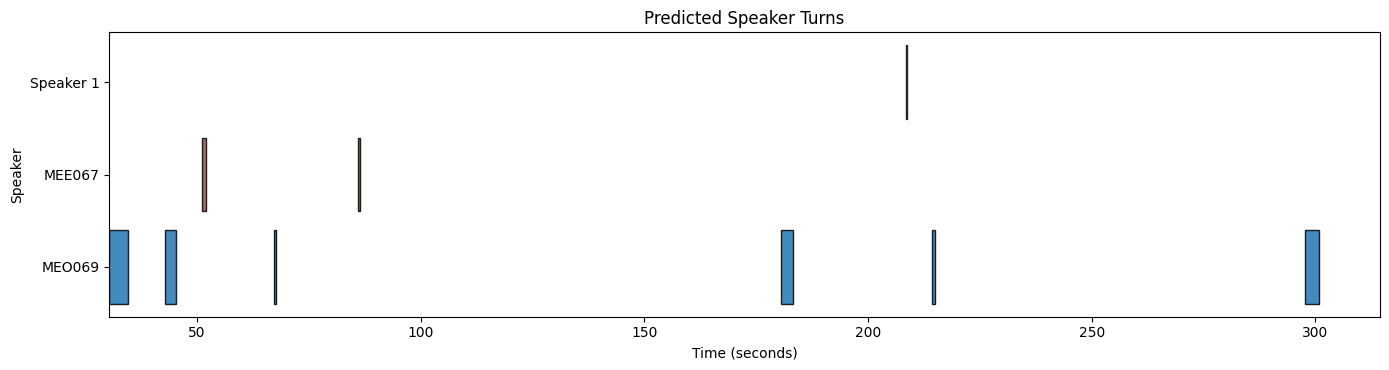

Saved speaker-turn visualization to: /kaggle/working/outputs/speaker_timeline.png


In [ ]:
timeline_path = os.path.join(OUTPUT_DIR, "speaker_timeline.png")
plot_speaker_timeline(results, timeline_path)
print("Saved speaker-turn visualization to:", timeline_path)